# Reti neurali con scikit-learn (MLP) — laboratorio completo e “divertente”

Notebook pronto per una lezione/lab (circa **4 ore**) senza TensorFlow.

Requisiti:
- Python (quello che avete già)
- pacchetti: `numpy`, `pandas`, `matplotlib`, `scikit-learn`

Installazione (da terminale):
```bash
pip install -U numpy pandas matplotlib scikit-learn
```

Obiettivi:
1. Capire **perché** servono modelli non lineari
2. Capire cos’è una **rete neurale feed-forward** (MLP)
3. Fare esperimenti con: architettura, attivazioni, overfitting, regularizzazione
4. Esempi “wow”: **XOR**, **moons/circles**, **digits** (immagini 8×8)


## 0) Setup

In [1]:
# Se serve (una sola volta), da notebook:
# %pip install -U numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Utility: grafici e decision boundary (senza seaborn)

In [2]:
def plot_2d_dataset(X, y, title="Dataset", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    return ax

def plot_decision_boundary(predict_fn, X, y, title="Decision boundary", ax=None, grid_step=0.02):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step),
                         np.arange(y_min, y_max, grid_step))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    return ax


---

## 1) Problema non lineare: `make_moons`

Partiamo con un dataset in 2D:
- è perfetto per *vedere* cosa succede
- un modello lineare fatica


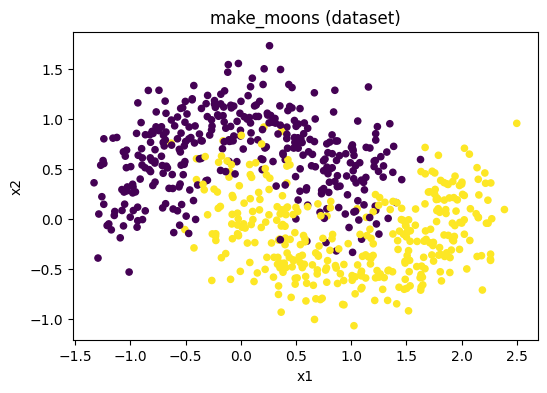

In [3]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=700, noise=0.25, random_state=42)

fig, ax = plt.subplots(figsize=(6,4))
plot_2d_dataset(X, y, title="make_moons (dataset)", ax=ax)
plt.show()


### 1.1) Modello lineare: Logistic Regression (baseline)

Accuracy (Logistic Regression): 0.8914285714285715


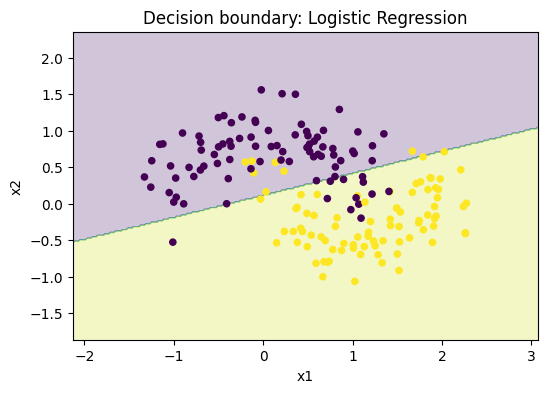

In [4]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

lin = LogisticRegression()
lin.fit(X_train, y_train)

pred = lin.predict(X_test)
print("Accuracy (Logistic Regression):", accuracy_score(y_test, pred))

fig, ax = plt.subplots(figsize=(6,4))
plot_decision_boundary(lambda g: lin.predict(g), X_test, y_test, title="Decision boundary: Logistic Regression", ax=ax)
plt.show()


### 1.2) Rete neurale: MLPClassifier

Una rete neurale MLP (Multi-Layer Perceptron) crea frontiere non lineari grazie alle attivazioni (ReLU/tanh).


Accuracy (MLP): 0.9428571428571428


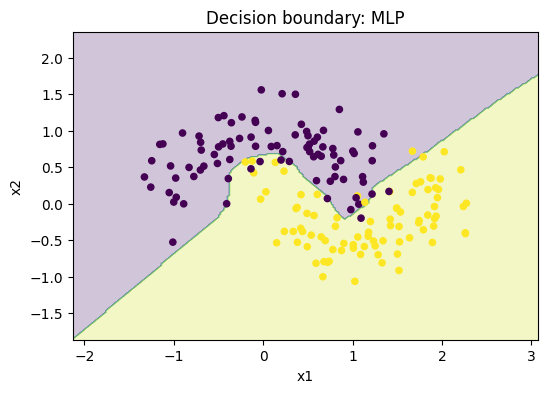

In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(32, 32),
                         activation="relu",
                         alpha=1e-4,
                         learning_rate_init=0.01,
                         max_iter=4000,
                         random_state=42))
])

mlp.fit(X_train, y_train)
pred = mlp.predict(X_test)
print("Accuracy (MLP):", accuracy_score(y_test, pred))

fig, ax = plt.subplots(figsize=(6,4))
plot_decision_boundary(lambda g: mlp.predict(g), X_test, y_test, title="Decision boundary: MLP", ax=ax)
plt.show()


---

## 2) XOR: il mini-problema che spiega perché serve la non-linearità

XOR non è separabile con una linea.


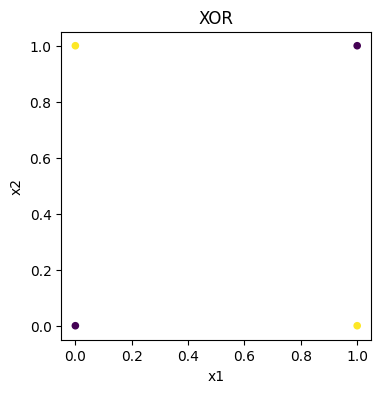

In [6]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0,1,1,0], dtype=int)

fig, ax = plt.subplots(figsize=(4,4))
plot_2d_dataset(X_xor, y_xor, title="XOR", ax=ax)
plt.show()


### 2.1) Modello lineare (fallisce)

In [7]:
lin_xor = LogisticRegression()
lin_xor.fit(X_xor, y_xor)
print("Predizioni Logistic Regression:", lin_xor.predict(X_xor))


Predizioni Logistic Regression: [0 0 0 0]


### 2.2) Rete neurale piccola (funziona)

In [8]:
xor_nn = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(4,),
                         activation="tanh",
                         alpha=1e-4,
                         learning_rate_init=0.1,
                         max_iter=8000,
                         random_state=1))
])

xor_nn.fit(X_xor, y_xor)
print("Predizioni MLP:", xor_nn.predict(X_xor))


Predizioni MLP: [0 1 1 0]


---

## 3) Esperimento “divertente”: cambiare architettura e vedere cosa succede

Giochiamo con:
- numero di layer e neuroni
- attivazione (`relu` vs `tanh`)
- regolarizzazione (`alpha`)


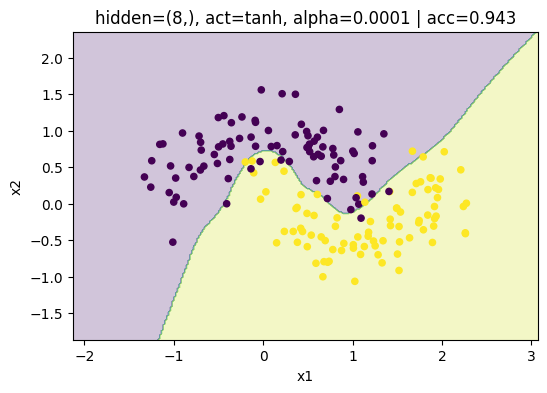

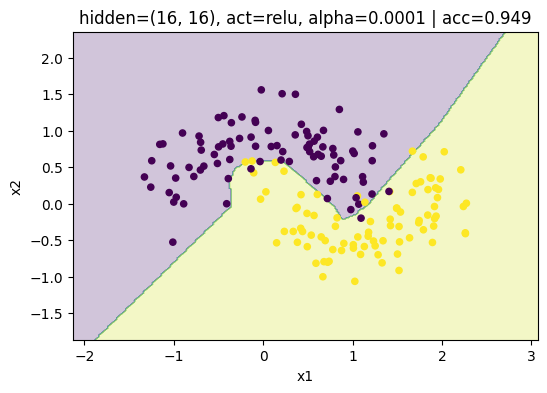

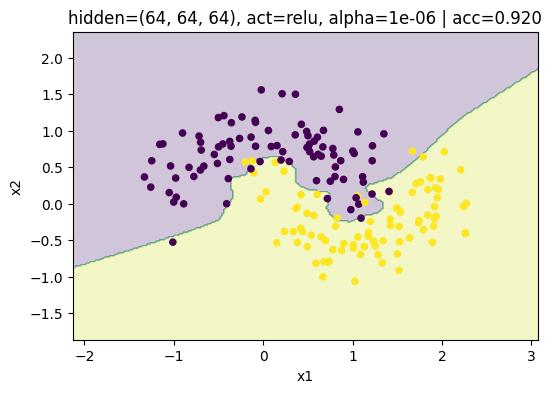

In [9]:
def train_and_plot_mlp(X_train, X_test, y_train, y_test, hidden=(32,32), activation="relu", alpha=1e-4, lr=0.01, iters=4000, title=None):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("nn", MLPClassifier(hidden_layer_sizes=hidden,
                             activation=activation,
                             alpha=alpha,
                             learning_rate_init=lr,
                             max_iter=iters,
                             random_state=42))
    ])
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)

    if title is None:
        title = f"hidden={hidden}, act={activation}, alpha={alpha} | acc={acc:.3f}"

    fig, ax = plt.subplots(figsize=(6,4))
    plot_decision_boundary(lambda g: model.predict(g), X_test, y_test, title=title, ax=ax)
    plt.show()
    return model, acc

# Prova 3 varianti (cambiale liberamente)
_ = train_and_plot_mlp(X_train, X_test, y_train, y_test, hidden=(8,), activation="tanh", alpha=1e-4, lr=0.05, iters=6000)
_ = train_and_plot_mlp(X_train, X_test, y_train, y_test, hidden=(16,16), activation="relu", alpha=1e-4, lr=0.01, iters=4000)
_ = train_and_plot_mlp(X_train, X_test, y_train, y_test, hidden=(64,64,64), activation="relu", alpha=1e-6, lr=0.01, iters=6000)


---

## 4) Overfitting: quando la rete “impara a memoria”

Con reti grandi e poca regolarizzazione (`alpha` basso), la rete può overfittare.
Scikit-learn non mostra facilmente la curva di loss per default, ma possiamo osservare:
- differenza tra score train e test
- matrice di confusione

Facciamo due reti:
- una “troppo potente”
- una più regolarizzata


BIG (rischio overfit) | train_acc=0.918 test_acc=0.931
Confusion matrix:
 [[83  5]
 [ 7 80]]
REG (più stabile) | train_acc=0.918 test_acc=0.937
Confusion matrix:
 [[81  7]
 [ 4 83]]


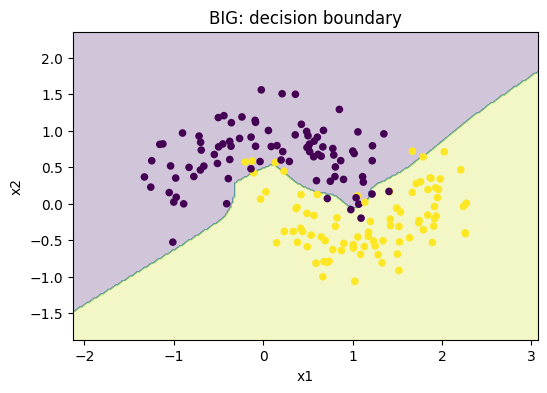

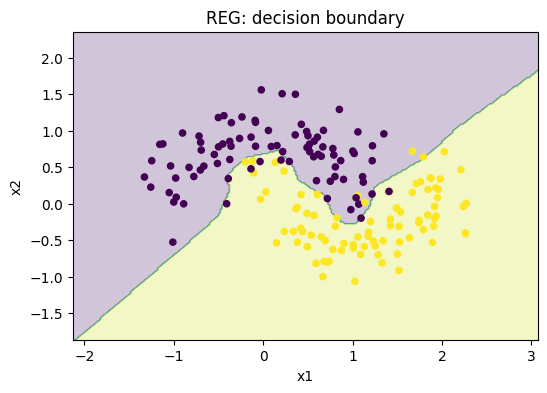

In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name="model"):
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    print(f"{name} | train_acc={train_acc:.3f} test_acc={test_acc:.3f}")

    pred = model.predict(X_test)

    print("Confusion matrix:\n", confusion_matrix(y_test, pred))

    return train_acc, test_acc


big = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(128,128,128),
                         activation="relu",
                         alpha=1e-8,
                         learning_rate_init=0.01,
                         max_iter=8000,
                         random_state=42))
])

big.fit(X_train, y_train)


reg = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(64,64),
                         activation="relu",
                         alpha=1e-3,  # più regolarizzazione
                         learning_rate_init=0.01,
                         max_iter=8000,
                         random_state=42))
])

reg.fit(X_train, y_train)


evaluate_model(big, X_train, y_train, X_test, y_test, name="BIG (rischio overfit)")
evaluate_model(reg, X_train, y_train, X_test, y_test, name="REG (più stabile)")


fig, ax = plt.subplots(figsize=(6,4))
plot_decision_boundary(lambda g: big.predict(g), X_test, y_test, title="BIG: decision boundary", ax=ax)
plt.show()


fig, ax = plt.subplots(figsize=(6,4))
plot_decision_boundary(lambda g: reg.predict(g), X_test, y_test, title="REG: decision boundary", ax=ax)
plt.show()


---

## 5) Altro dataset visivo: `make_circles`

Cerchi concentrici: perfetto per far vedere la non-linearità.


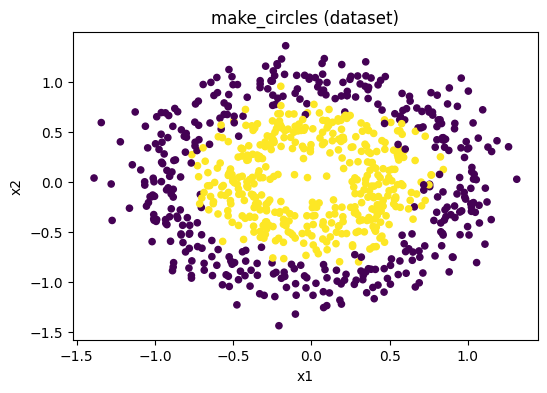

Accuracy Logistic Regression: 0.47
Accuracy MLP: 0.96


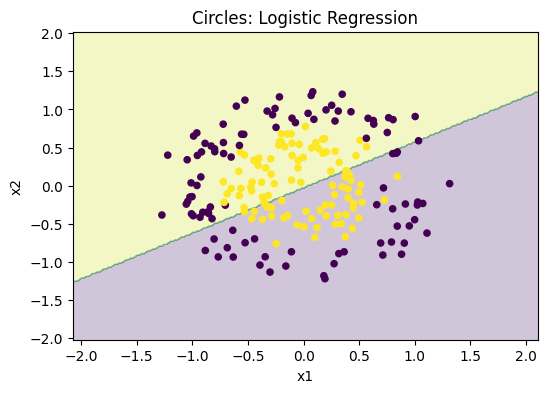

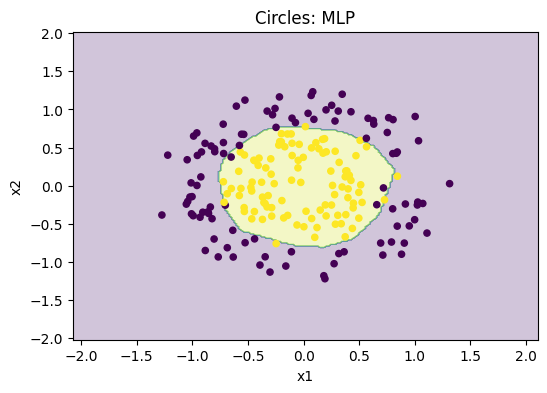

In [11]:
from sklearn.datasets import make_circles

Xc, yc = make_circles(n_samples=800, noise=0.15, factor=0.5, random_state=42)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.25, random_state=42, stratify=yc)

fig, ax = plt.subplots(figsize=(6,4))
plot_2d_dataset(Xc, yc, title="make_circles (dataset)", ax=ax)
plt.show()

lin_c = LogisticRegression().fit(Xc_train, yc_train)
print("Accuracy Logistic Regression:", lin_c.score(Xc_test, yc_test))

nn_c = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(32,32), activation="relu", alpha=1e-4, learning_rate_init=0.01, max_iter=6000, random_state=42))
]).fit(Xc_train, yc_train)
print("Accuracy MLP:", nn_c.score(Xc_test, yc_test))

fig, ax = plt.subplots(figsize=(6,4))
plot_decision_boundary(lambda g: lin_c.predict(g), Xc_test, yc_test, title="Circles: Logistic Regression", ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
plot_decision_boundary(lambda g: nn_c.predict(g), Xc_test, yc_test, title="Circles: MLP", ax=ax)
plt.show()


---

## 6) Immagini: riconoscere cifre con `load_digits` (8×8)

È l’esempio “wow” senza TensorFlow: immagini piccole, rete neurale, accuracy alta.

Passi:
1. carichiamo `digits`
2. visualizziamo esempi
3. alleniamo un MLP
4. guardiamo gli errori


X: (1797, 64) y: (1797,) images: (1797, 8, 8)


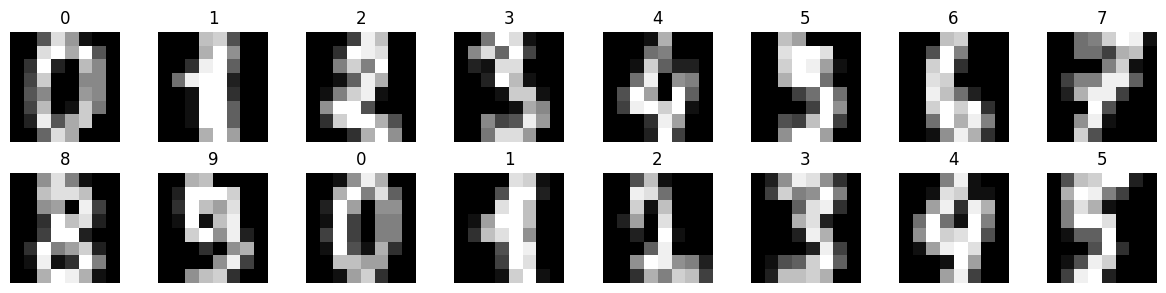

In [12]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data        # (n_samples, 64) = 8x8 appiattito
y = digits.target
images = digits.images # (n_samples, 8, 8)

print("X:", X.shape, "y:", y.shape, "images:", images.shape)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(str(y[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


### 6.1) Train/test + MLP

In [13]:
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

digits_nn = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(64,64),
                         activation="relu",
                         alpha=1e-4,
                         learning_rate_init=0.01,
                         max_iter=4000,
                         random_state=42))
])

digits_nn.fit(Xd_train, yd_train)

pred = digits_nn.predict(Xd_test)
print("Accuracy:", accuracy_score(yd_test, pred))
print(classification_report(yd_test, pred))


Accuracy: 0.9777777777777777
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        45
           1       0.96      0.96      0.96        46
           2       0.96      1.00      0.98        44
           3       0.98      1.00      0.99        46
           4       1.00      0.98      0.99        45
           5       1.00      0.98      0.99        46
           6       1.00      1.00      1.00        45
           7       1.00      1.00      1.00        45
           8       0.93      0.91      0.92        43
           9       0.96      0.98      0.97        45

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



### 6.2) Dove sbaglia? (divertente)

Errori totali: 10 su 450


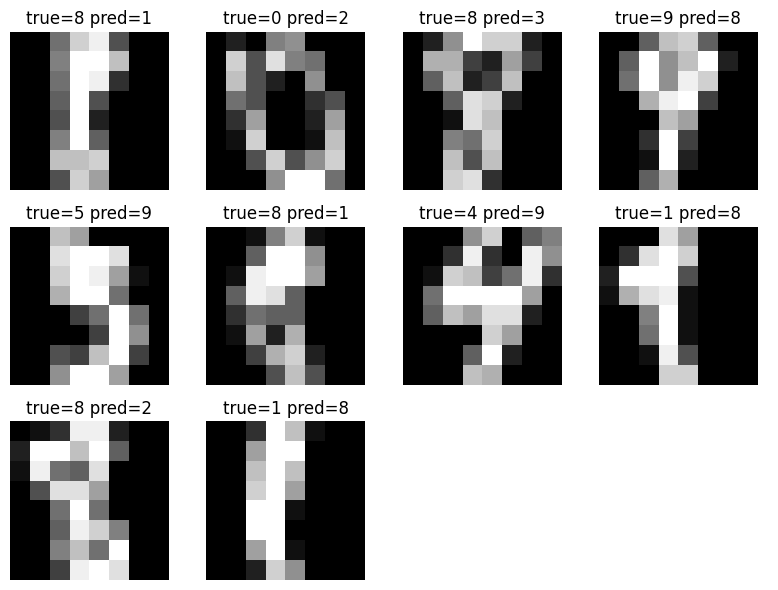

In [14]:
wrong_idx = np.where(pred != yd_test)[0]
print("Errori totali:", len(wrong_idx), "su", len(yd_test))

# Mostra fino a 12 errori
n_show = min(12, len(wrong_idx))
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for k in range(n_show):
    ax = axes.ravel()[k]
    idx = wrong_idx[k]
    ax.imshow(Xd_test[idx].reshape(8,8), cmap="gray")
    ax.set_title(f"true={yd_test[idx]} pred={pred[idx]}")
    ax.axis("off")

# Se ci sono meno di 12, spegni gli assi rimanenti
for k in range(n_show, 12):
    axes.ravel()[k].axis("off")

plt.tight_layout()
plt.show()


---

## 7) Sfida finale (in classe)

Obiettivo: migliorare l’accuracy su digits.

Cose da provare:
- più neuroni o più layer
- `activation="tanh"` vs `"relu"`
- `alpha` (regolarizzazione)
- `learning_rate_init`

Regola: cambiate UNA cosa alla volta e annotate i risultati.

Compito: trovate una configurazione che batta questa baseline.


In [15]:
baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(64,64),
                         activation="relu",
                         alpha=1e-4,
                         learning_rate_init=0.01,
                         max_iter=4000,
                         random_state=42))
])

baseline.fit(Xd_train, yd_train)
print("Baseline accuracy:", baseline.score(Xd_test, yd_test))

# Scrivete qui la vostra "configurazione campione"
champion = Pipeline([
    ("scaler", StandardScaler()),
    ("nn", MLPClassifier(hidden_layer_sizes=(128,64,32),
                         activation="relu",
                         alpha=1e-5,
                         learning_rate_init=0.01,
                         max_iter=6000,
                         random_state=42))
])

champion.fit(Xd_train, yd_train)
print("Champion accuracy:", champion.score(Xd_test, yd_test))


Baseline accuracy: 0.9777777777777777
Champion accuracy: 0.9711111111111111


---

## 8) Mini-check finale (domande rapide)

1. Perché Logistic Regression fallisce su moons/circles?
2. Perché XOR è importante?
3. Cosa fa una funzione di attivazione?
4. Cos’è `alpha` nell’MLP di scikit-learn?
5. Perché standardizzare (StandardScaler) aiuta molto?
